# Analysing UK Road Traffic Accidents

This portfolio project examines reported road traffic accidents in Great Britain using Python, SQLite, statistical testing, association-rule mining, spatial clustering, and time-series forecasting.

The analysis focuses primarily on 2018 accident records, with 2017–2018 data used for training selected forecasting models and 2019 data used for evaluation.


## Defining the Project Objectives

The analysis aims to:

- examine how accident frequency changes by hour and day of the week;
- compare temporal patterns for motorcycles and pedestrian casualties;
- identify combinations of road, weather, lighting, and severity conditions using Apriori association rules;
- locate accident concentrations in West Yorkshire using K-Means and DBSCAN;
- forecast weekly accident counts for high-volume police-force areas; and
- estimate short-term accident counts for high-incident West Yorkshire LSOAs.

The project combines descriptive, statistical, spatial, and predictive techniques to produce evidence that may support road-safety planning.


## Describing the Dataset

The SQLite database contains four principal tables:

- `accident`: accident-level time, location, severity, road, and environmental information;
- `vehicle`: vehicle-level characteristics linked through the accident index;
- `casualty`: casualty-level characteristics linked through the accident index; and
- `lsoa`: geographic lookup information.

The data represent police-reported injury accidents. Therefore, the findings do not include unreported incidents or damage-only collisions.


## Importing the Required Libraries

The notebook uses data-processing, statistical, spatial, association-rule, and forecasting libraries. A missing `mlxtend` installation is handled automatically before importing the Apriori functions.


In [1]:
# Importing libraries

import sqlite3
import subprocess
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chisquare, chi2_contingency
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Importing Apriori functions and installing mlxtend only when required
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])
    from mlxtend.frequent_patterns import apriori, association_rules


## Connecting to the Accident Database

The database file is opened through SQLite and the available tables are checked before analysis.

> **Reproducibility note:** place the SQLite database in the notebook directory or update `db_path` before running the analysis.


In [2]:
# Step 2: Connect to the database

db_path = "accident_data_v1.0.0_2023 (1).db"

conn = sqlite3.connect(db_path)

# Check what tables are available
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,accident
1,casualty
2,vehicle
3,lsoa


## Loading the Accident, Vehicle, and Casualty Tables

The three main relational tables are loaded into pandas DataFrames. Their dimensions and a sample of the accident table are displayed to confirm that the data were imported correctly.


In [3]:
# Loading the three main tables

accident = pd.read_sql_query("SELECT * FROM accident", conn)
vehicle = pd.read_sql_query("SELECT * FROM vehicle", conn)
casualty = pd.read_sql_query("SELECT * FROM casualty", conn)

print(accident.shape)
print(vehicle.shape)
print(casualty.shape)

accident.head()

(461352, 36)
(849091, 28)
(600332, 19)


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2017010001708,2017,010001708,532920.0,196330.0,-0.080107,51.650061,1,1,2,...,0,4,1,1,0,0,1,1,2,E01001450
1,2017010009342,2017,010009342,526790.0,181970.0,-0.173845,51.522425,1,3,2,...,0,4,1,2,0,0,1,1,2,E01004702
2,2017010009344,2017,010009344,535200.0,181260.0,-0.052969,51.514096,1,3,3,...,0,4,1,1,0,0,1,1,2,E01004298
3,2017010009348,2017,010009348,534340.0,193560.0,-0.060658,51.624832,1,3,2,...,4,4,2,2,0,0,1,1,2,E01001429
4,2017010009350,2017,010009350,533680.0,187820.0,-0.072372,51.573408,1,2,1,...,5,4,1,2,0,0,1,1,2,E01001808


## Preparing the Accident Records

Dates and times are converted into analysis-ready formats. Additional temporal variables are created, including year, month, day name, and hour. Records from 2018 are then selected for the main descriptive analysis.

Invalid or missing time values are treated as unavailable rather than forced into an incorrect category.


In [4]:
# Basic cleaning

# Convert date column to datetime
accident["date"] = pd.to_datetime(accident["date"], errors="coerce", dayfirst=True)

# Create useful date/time columns
accident["year"] = accident["date"].dt.year
accident["month"] = accident["date"].dt.month
accident["day_name"] = accident["date"].dt.day_name()

# Extract hour from the time column
accident["time"] = accident["time"].astype(str)
accident["hour"] = pd.to_numeric(accident["time"].str[:2], errors="coerce")

# Remove impossible hours
accident.loc[(accident["hour"] < 0) | (accident["hour"] > 23), "hour"] = np.nan

# Filter 2018 accident data for most tasks
accident_2018 = accident[accident["accident_year"] == 2018].copy()

print("Number of accidents in 2018:", len(accident_2018))
accident_2018.head()

Number of accidents in 2018: 122635


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,year,month,day_name,hour
129982,2018010080971,2018,010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,...,0,0,1,1,2,E01000854,2018,1,Monday,1.0
129983,2018010080973,2018,010080973,542020.0,184290.0,0.046471,51.539651,1,3,1,...,0,0,1,1,2,E01003531,2018,1,Monday,0.0
129984,2018010080974,2018,010080974,531720.0,182910.0,-0.102474,51.529746,1,3,2,...,0,0,1,1,2,E01002723,2018,1,Monday,0.0
129985,2018010080981,2018,010080981,541450.0,183220.0,0.037828,51.530179,1,2,2,...,0,0,1,1,2,E01003492,2018,1,Monday,3.0
129986,2018010080982,2018,010080982,543580.0,176500.0,0.065781,51.469258,1,2,2,...,0,0,1,1,2,E01001682,2018,1,Monday,2.0


## Translating Coded Variables

Several source fields are stored as numeric codes. Readable labels are created for severity, weekday, weather, road-surface condition, lighting, and urban or rural location.


In [5]:
# Add simple labels for coded columns

severity_labels = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

day_labels = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

weather_labels = {
    1: "Fine",
    2: "Raining",
    3: "Snowing",
    4: "Fine with high winds",
    5: "Raining with high winds",
    6: "Snowing with high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown"
}

surface_labels = {
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood",
    6: "Oil or diesel",
    7: "Mud"
}

light_labels = {
    1: "Daylight",
    4: "Darkness lights lit",
    5: "Darkness lights unlit",
    6: "Darkness no lighting",
    7: "Darkness unknown lighting"
}

accident_2018["severity"] = accident_2018["accident_severity"].map(severity_labels)
accident_2018["day"] = accident_2018["day_of_week"].map(day_labels)
accident_2018["weather"] = accident_2018["weather_conditions"].map(weather_labels)
accident_2018["surface"] = accident_2018["road_surface_conditions"].map(surface_labels)
accident_2018["light"] = accident_2018["light_conditions"].map(light_labels)

## Exploring Accident Patterns by Hour and Day

Accident counts are aggregated by hour and weekday. Bar charts and a day–hour heatmap identify temporal concentrations.

Chi-square goodness-of-fit tests assess whether the observed distributions differ from uniform patterns. Statistical significance indicates uneven temporal distribution, not causation.


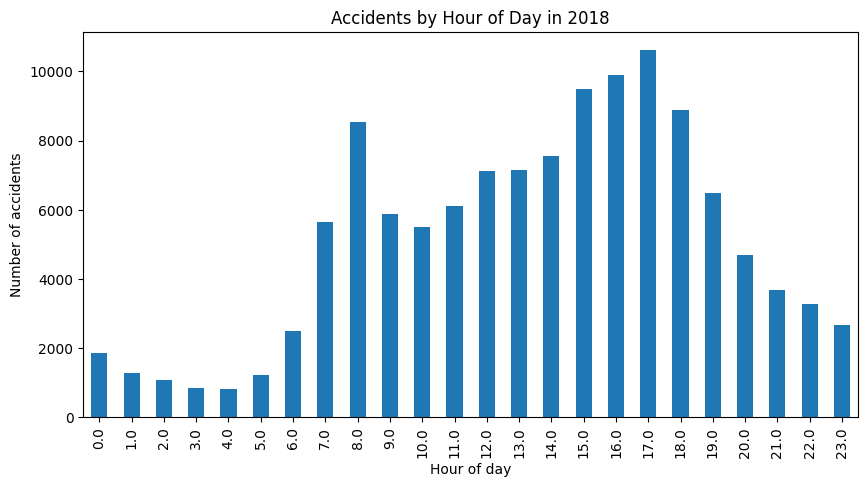

Chi-square: 44844.94181106535
p-value: 0.0


In [6]:
# Accidents by hour

hour_counts = accident_2018["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind="bar")
plt.title("Accidents by Hour of Day in 2018")
plt.xlabel("Hour of day")
plt.ylabel("Number of accidents")
plt.show()

# Statistical test
chi_hour, p_hour = chisquare(hour_counts)

print("Chi-square:", chi_hour)
print("p-value:", p_hour)

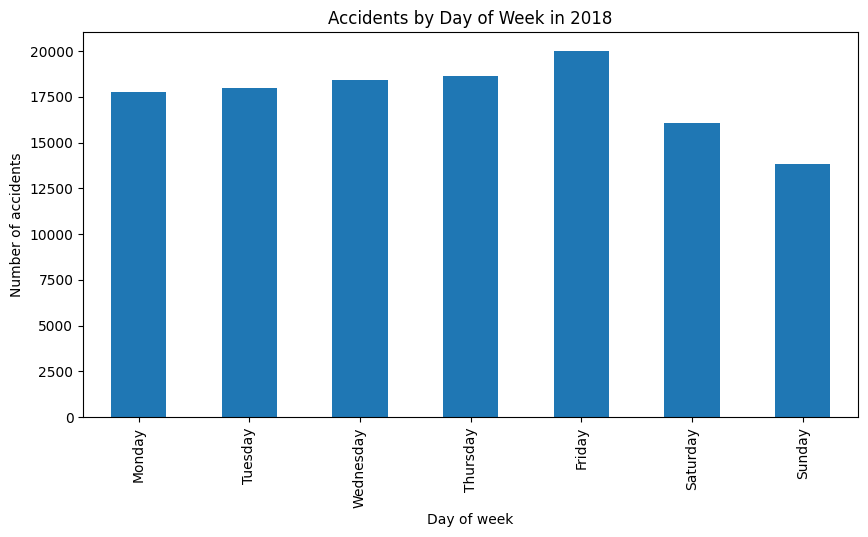

Chi-square test for accident day pattern
Chi-square: 1397.3962082602845
p-value: 8.872809264872976e-299


In [7]:
# Accidents by day of week

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = accident_2018["day"].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
day_counts.plot(kind="bar")
plt.title("Accidents by Day of Week in 2018")
plt.xlabel("Day of week")
plt.ylabel("Number of accidents")
plt.show()

# Statistical test
chi_day, p_day = chisquare(day_counts)

print("Chi-square test for accident day pattern")
print("Chi-square:", chi_day)
print("p-value:", p_day)

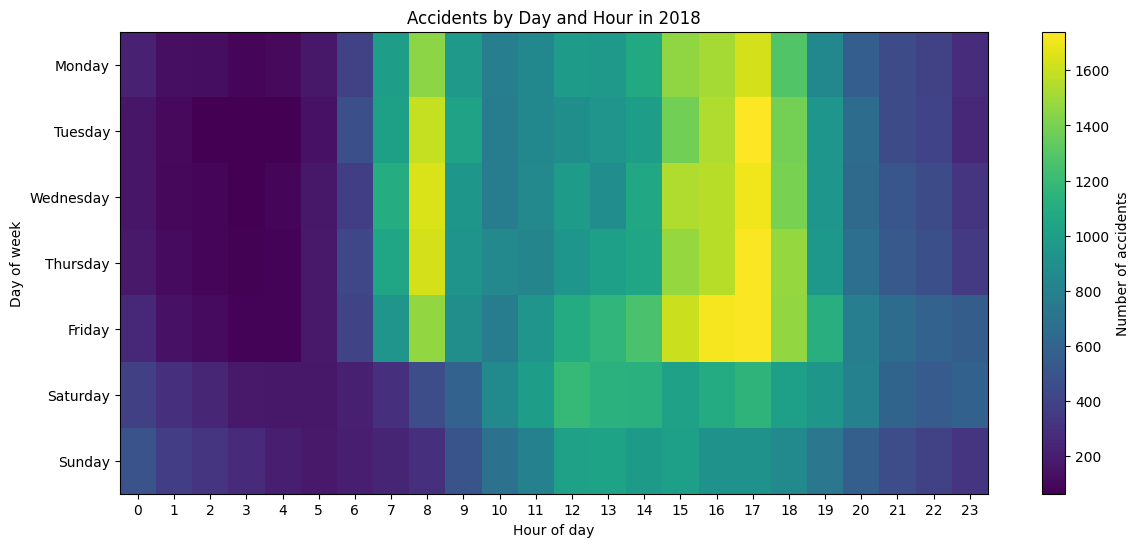

In [8]:
# Heatmap by day and hour

heatmap_data = pd.crosstab(accident_2018["day"], accident_2018["hour"])
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Number of accidents")
plt.title("Accidents by Day and Hour in 2018")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.xticks(range(24), range(24))
plt.yticks(range(len(day_order)), day_order)
plt.show()

### Interpreting the Temporal Patterns

The 2018 data contain **122,635 accident records**. Accident frequency rises during commuting and afternoon travel periods, reaching its highest level around **17:00**. Friday records the largest weekday total, while Sunday records the lowest.

The heatmap reinforces the interaction between weekday and hour, with stronger concentrations during weekday morning and late-afternoon travel periods.


## Analysing Motorcycle Accident Patterns

Vehicle records are joined to accident-level time information and grouped into:

- 125cc and under;
- over 125cc and up to 500cc; and
- over 500cc.

Hourly and weekday distributions are compared, and a chi-square test evaluates the relationship between motorcycle category and weekday pattern.


In [9]:
# Motorcycle accidents by hour and day

vehicle_2018 = vehicle[vehicle["accident_year"] == 2018].copy()

# Join accident time data to vehicle data
motorcycle = vehicle_2018.merge(
    accident_2018[["accident_index", "hour", "day"]],
    on="accident_index",
    how="inner"
)

# Create motorcycle groups
def bike_group(x):
    if x in [2, 3]:
        return "125cc and under"
    elif x == 4:
        return "Over 125cc to 500cc"
    elif x == 5:
        return "Over 500cc"
    else:
        return np.nan

motorcycle["bike_group"] = motorcycle["vehicle_type"].apply(bike_group)

# Keep only motorbikes needed for the assignment
motorcycle = motorcycle.dropna(subset=["bike_group"])

motorcycle.head()

,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type,hour,day,bike_group
17,238943,2018010080990,2018,010080990,2,3,0,18,7,3,...,6,108,1,1,-1,6,1,0.0,Monday,125cc and under
18,238944,2018010080992,2018,010080992,1,2,0,18,7,3,...,6,124,1,14,-1,2,1,3.0,Monday,125cc and under
25,238951,2018010080996,2018,010080996,2,3,0,18,5,1,...,6,125,1,8,-1,4,1,3.0,Monday,125cc and under
27,238953,2018010081002,2018,010081002,1,5,0,18,5,1,...,7,680,1,12,-1,4,1,7.0,Monday,Over 500cc
32,238958,2018010081009,2018,010081009,2,3,0,18,1,5,...,6,125,1,9,-1,3,1,10.0,Monday,125cc and under


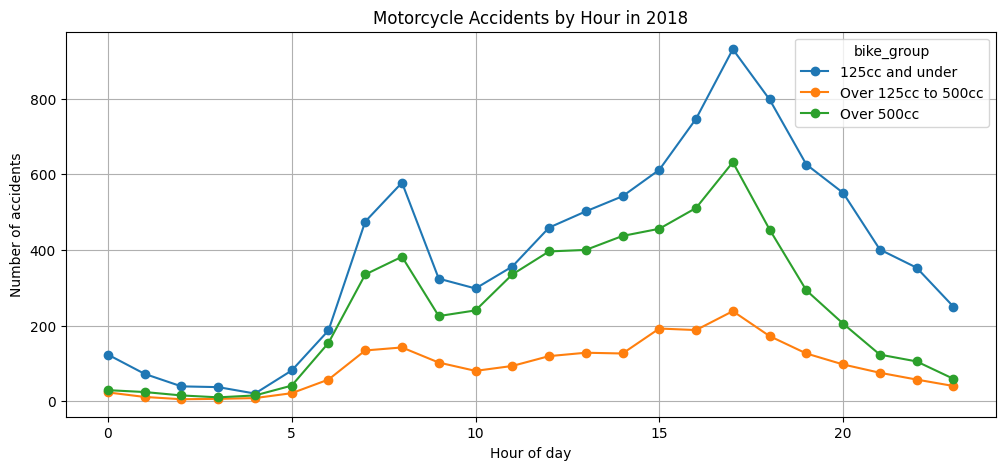

In [10]:
# Motorcycle accidents by hour
bike_hour = pd.crosstab(motorcycle["hour"], motorcycle["bike_group"])

bike_hour.plot(figsize=(12, 5), marker="o")
plt.title("Motorcycle Accidents by Hour in 2018")
plt.xlabel("Hour of day")
plt.ylabel("Number of accidents")
plt.grid(True)
plt.show()

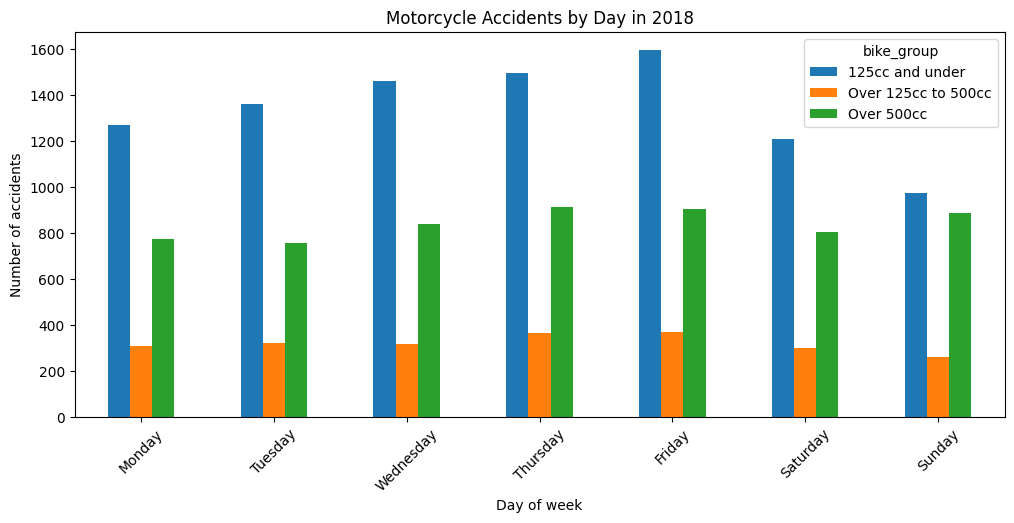

Chi-square test for motorcycle category and day
Chi-square: 87.94052331818645
p-value: 1.234940160590855e-13


In [11]:
# Motorcycle accidents by day
bike_day = pd.crosstab(motorcycle["day"], motorcycle["bike_group"])
bike_day = bike_day.reindex(day_order)

bike_day.plot(kind="bar", figsize=(12, 5))
plt.title("Motorcycle Accidents by Day in 2018")
plt.xlabel("Day of week")
plt.ylabel("Number of accidents")
plt.xticks(rotation=45)
plt.show()

# Chi-square test
chi_bike, p_bike, dof, expected = chi2_contingency(bike_day)

print("Chi-square test for motorcycle category and day")
print("Chi-square:", chi_bike)
print("p-value:", p_bike)

### Interpreting the Motorcycle Results

The analysis includes **17,478 motorcycle vehicle records**. Motorcycles of 125cc and under form the largest group, and all categories show a pronounced late-afternoon peak. Larger motorcycles show relatively stronger weekend involvement.

The significant chi-square result indicates that weekday patterns vary across motorcycle categories.


## Analysing Pedestrian Casualties

Pedestrian records are selected from the casualty table and linked to accident dates and times. Hourly and weekday patterns are examined, with separate chi-square tests assessing whether pedestrian casualties are evenly distributed across time.


In [12]:
# Pedestrian casualties by hour and day

casualty_2018 = casualty[casualty["accident_year"] == 2018].copy()

# Join accident time data to casualty data
pedestrian = casualty_2018.merge(
    accident_2018[["accident_index", "hour", "day"]],
    on="accident_index",
    how="inner"
)

# Pedestrians have casualty_class = 3
pedestrian = pedestrian[pedestrian["casualty_class"] == 3]

print("Number of pedestrian casualties:", len(pedestrian))
pedestrian.head()

Number of pedestrian casualties: 22432


,casualty_index,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,...,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,hour,day
2,170995,2018010080973,2018,010080973,1,1,3,1,29,6,...,5,1,0,0,2,0,1,3,0.0,Monday
15,171008,2018010080993,2018,010080993,1,1,3,1,46,8,...,5,4,0,0,2,0,1,1,6.0,Monday
16,171009,2018010080994,2018,010080994,1,1,3,1,19,4,...,5,9,0,0,2,0,1,2,5.0,Monday
32,171025,2018010081035,2018,010081035,1,1,3,2,62,9,...,5,3,0,0,2,0,-1,-1,14.0,Monday
34,171027,2018010081054,2018,010081054,1,1,3,1,8,2,...,10,9,0,0,2,0,1,1,16.0,Monday


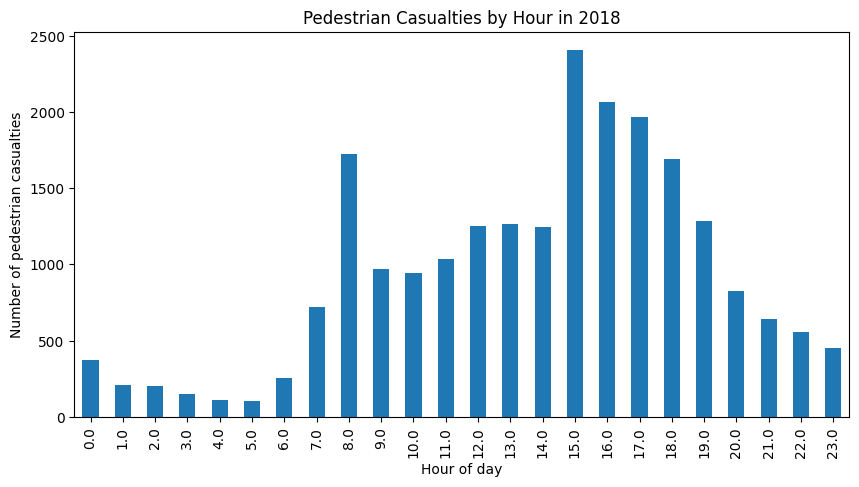

Pedestrian hour p-value: 0.0


In [13]:
# Pedestrians by hour
ped_hour = pedestrian["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ped_hour.plot(kind="bar")
plt.title("Pedestrian Casualties by Hour in 2018")
plt.xlabel("Hour of day")
plt.ylabel("Number of pedestrian casualties")
plt.show()

chi_ped_hour, p_ped_hour = chisquare(ped_hour)

print("Pedestrian hour p-value:", p_ped_hour)

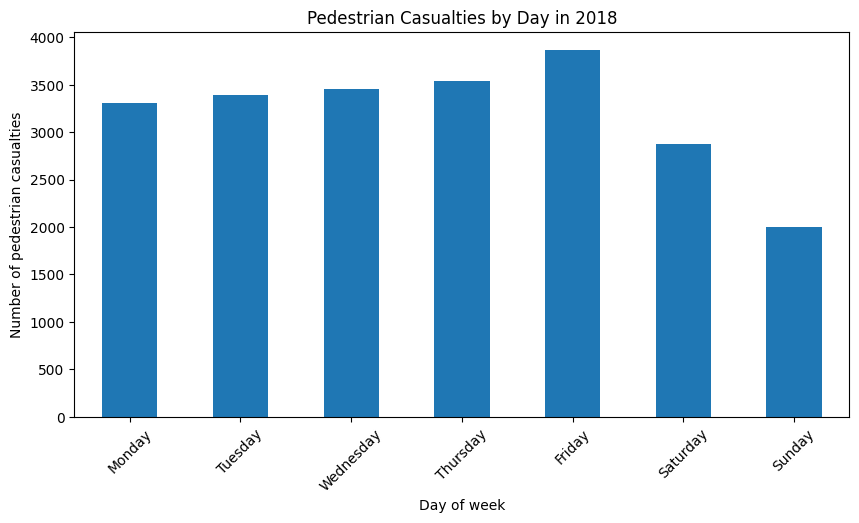

Pedestrian day p-value: 1.0059628800710597e-144


In [14]:
# Pedestrians by day
ped_day = pedestrian["day"].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
ped_day.plot(kind="bar")
plt.title("Pedestrian Casualties by Day in 2018")
plt.xlabel("Day of week")
plt.ylabel("Number of pedestrian casualties")
plt.xticks(rotation=45)
plt.show()

chi_ped_day, p_ped_day = chisquare(ped_day)

print("Pedestrian day p-value:", p_ped_day)

### Interpreting the Pedestrian Results

The 2018 data include **22,432 pedestrian casualties**. The strongest concentration occurs between **15:00 and 17:00**, overlapping with school finishing times, shopping activity, and the evening commute.

Friday has the highest pedestrian-casualty total, while Sunday has the lowest.


## Mining Accident Conditions with Apriori

Severity, weather, road-surface condition, lighting, speed limit, and urban or rural location are transformed into transaction-style items.

Apriori identifies frequent combinations, and association rules are evaluated using support, confidence, and lift.

> Association rules describe co-occurrence rather than causation.


In [15]:
# Apriori algorithm for accident severity

# Select variables that may affect accident severity
apriori_data = accident_2018[
    ["severity", "weather", "surface", "light", "speed_limit", "urban_or_rural_area"]
].copy()

# Make all values text
apriori_data["speed_limit"] = "Speed limit " + apriori_data["speed_limit"].astype(str)
apriori_data["urban_or_rural_area"] = "Urban/rural " + apriori_data["urban_or_rural_area"].astype(str)

# Add column names into values to make the rules clearer
for col in apriori_data.columns:
    apriori_data[col] = col + ": " + apriori_data[col].astype(str)

# Convert to one-hot encoded format
apriori_encoded = pd.get_dummies(apriori_data)

# Run Apriori
frequent_items = apriori(
    apriori_encoded,
    min_support=0.01,
    use_colnames=True
)

# Create association rules
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.3
)

# Keep rules where severity is the result
severity_rules = rules[
    rules["consequents"].astype(str).str.contains("severity")
]

# Sort strongest rules first
severity_rules = severity_rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

severity_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

,antecedents,consequents,support,confidence,lift
3762,"(weather_weather: Raining, speed_limit_speed_l...","(light_light: Darkness lights lit, urban_or_ru...",0.018233,0.307312,6.327598
3752,"(light_light: Darkness lights lit, weather_wea...",(urban_or_rural_area_urban_or_rural_area: Urba...,0.018233,0.709616,6.124983
3786,"(weather_weather: Raining, speed_limit_speed_l...",(urban_or_rural_area_urban_or_rural_area: Urba...,0.021332,0.701340,6.053554
2874,"(weather_weather: Raining, speed_limit_speed_l...",(urban_or_rural_area_urban_or_rural_area: Urba...,0.041448,0.698598,6.029883
3755,"(light_light: Darkness lights lit, surface_sur...",(urban_or_rural_area_urban_or_rural_area: Urba...,0.018233,0.339508,6.010621
3757,(urban_or_rural_area_urban_or_rural_area: Urba...,"(light_light: Darkness lights lit, severity_se...",0.018233,0.351351,6.004456
3782,(urban_or_rural_area_urban_or_rural_area: Urba...,"(surface_surface: Wet or damp, severity_severi...",0.021332,0.611644,5.935659
3751,"(light_light: Darkness lights lit, urban_or_ru...","(surface_surface: Wet or damp, severity_severi...",0.018233,0.611096,5.930343
2873,(urban_or_rural_area_urban_or_rural_area: Urba...,"(surface_surface: Wet or damp, severity_severi...",0.041448,0.608160,5.901850
3794,"(weather_weather: Raining, speed_limit_speed_l...","(surface_surface: Wet or damp, urban_or_rural_...",0.021332,0.359538,5.846966


### Interpreting the Association Rules

The strongest rules involve combinations of environmental and road-context variables, including rain, wet surfaces, lighting conditions, speed limits, and urban or rural settings.

These recurring contexts may support deeper investigation, but exposure and confounding factors must be considered before drawing policy conclusions.


## Identifying West Yorkshire Accident Hotspots

West Yorkshire accidents are selected and records without valid coordinates are removed.

- **K-Means** creates a fixed number of broad spatial zones.
- **DBSCAN** detects dense local concentrations and labels isolated observations as noise.

Coordinates are standardised before clustering.


In [16]:
# West Yorkshire clustering

# West Yorkshire police force code is 13
west_yorkshire = accident_2018[accident_2018["police_force"] == 13].copy()

# Use only rows with coordinates
west_yorkshire = west_yorkshire.dropna(subset=["latitude", "longitude"])

print("West Yorkshire accidents:", len(west_yorkshire))
west_yorkshire.head()

West Yorkshire accidents: 4132


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,lsoa_of_accident_location,year,month,day_name,hour,severity,day,weather,surface,light
172998,20181342H0071,2018,1342H0071,441467.0,416440.0,-1.374243,53.642853,13,3,1,...,E01011791,2018,2,Saturday,1.0,Slight,Saturday,Fine,Dry,Darkness no lighting
172999,20181347I1326,2018,1347I1326,431902.0,434864.0,-1.517027,53.809110,13,3,2,...,E01011677,2018,2,Sunday,17.0,Slight,Sunday,Fine,Dry,Darkness unknown lighting
173000,2018134971519,2018,134971519,421169.0,440497.0,-1.679628,53.860282,13,3,1,...,E01011276,2018,2,Wednesday,19.0,Slight,Wednesday,Raining,Wet or damp,Darkness lights lit
173001,2018134981404,2018,134981404,429857.0,434402.0,-1.548126,53.805079,13,3,3,...,E01033008,2018,2,Thursday,18.0,Slight,Thursday,Fine,Dry,Darkness unknown lighting
173002,2018135110070,2018,135110070,411057.0,435169.0,-1.833560,53.812706,13,3,1,...,E01010672,2018,1,Monday,0.0,Slight,Monday,Fine,Wet or damp,Darkness lights lit


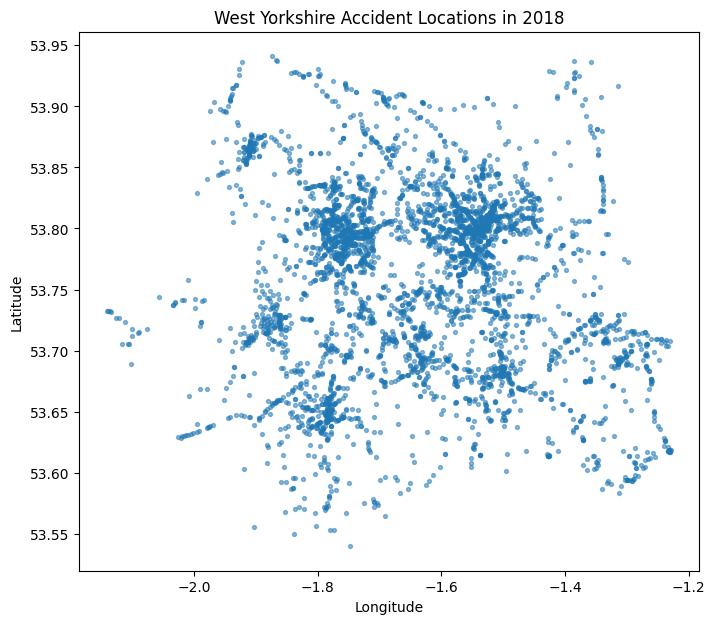

In [17]:
# Plot accident locations
plt.figure(figsize=(8, 7))
plt.scatter(
    west_yorkshire["longitude"],
    west_yorkshire["latitude"],
    s=8,
    alpha=0.5
)
plt.title("West Yorkshire Accident Locations in 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

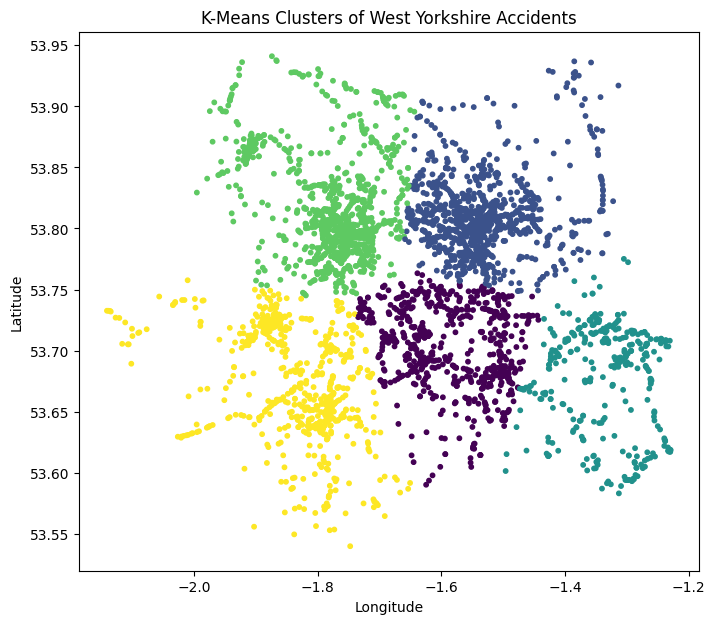

In [18]:
# Prepare coordinates for clustering
coords = west_yorkshire[["latitude", "longitude"]]

# Standardise coordinates
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
west_yorkshire["kmeans_cluster"] = kmeans.fit_predict(coords_scaled)

# Plot K-Means clusters
plt.figure(figsize=(8, 7))
plt.scatter(
    west_yorkshire["longitude"],
    west_yorkshire["latitude"],
    c=west_yorkshire["kmeans_cluster"],
    s=10
)
plt.title("K-Means Clusters of West Yorkshire Accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

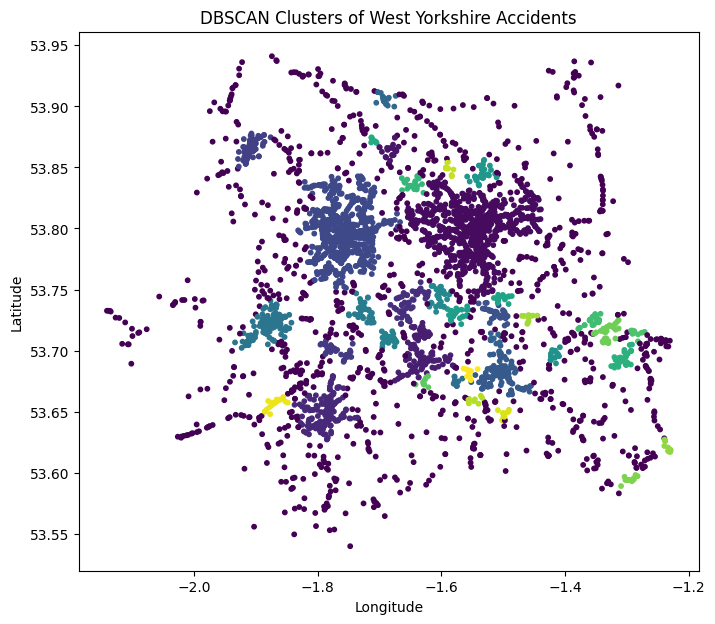

In [19]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.08, min_samples=10)
west_yorkshire["dbscan_cluster"] = dbscan.fit_predict(coords_scaled)

# Plot DBSCAN clusters
plt.figure(figsize=(8, 7))
plt.scatter(
    west_yorkshire["longitude"],
    west_yorkshire["latitude"],
    c=west_yorkshire["dbscan_cluster"],
    s=10
)
plt.title("DBSCAN Clusters of West Yorkshire Accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [20]:
# Summary of K-Means clusters
cluster_summary = west_yorkshire.groupby("kmeans_cluster").agg(
    number_of_accidents=("accident_index", "count"),
    average_latitude=("latitude", "mean"),
    average_longitude=("longitude", "mean"),
    serious_accidents=("accident_severity", lambda x: (x == 2).sum()),
    fatal_accidents=("accident_severity", lambda x: (x == 1).sum())
)

cluster_summary

,number_of_accidents,average_latitude,average_longitude,serious_accidents,fatal_accidents
kmeans_cluster,,,,,
0,753,53.703855,-1.587091,135,13
1,1219,53.808301,-1.535457,226,16
2,369,53.675605,-1.336337,81,10
3,1109,53.816688,-1.775155,182,16
4,682,53.671030,-1.831212,115,8


### Interpreting the Spatial Clusters

The analysis retains **4,132 West Yorkshire accidents**. K-Means separates the records into five spatial groups, with the largest cluster containing more than 1,200 accidents.

Combining broad K-Means zones with denser DBSCAN hotspots supports geographically targeted road-safety investigation.


## Forecasting Weekly Accidents by Police-Force Area

The three highest-volume police-force areas are selected automatically. Weekly counts from 2017 and 2018 are used for training, while 2019 is retained for out-of-sample evaluation.

Exponential Smoothing provides an interpretable baseline, evaluated using MAE, RMSE, and annual totals.


In [21]:
# Weekly time-series forecasting

# Use 2017, 2018 and 2019
accident_ts = accident[accident["accident_year"].isin([2017, 2018, 2019])].copy()

# Choose three police forces with high accident counts
chosen_forces = accident_ts["police_force"].value_counts().head(3).index.tolist()

chosen_forces

[1, 20, 46]

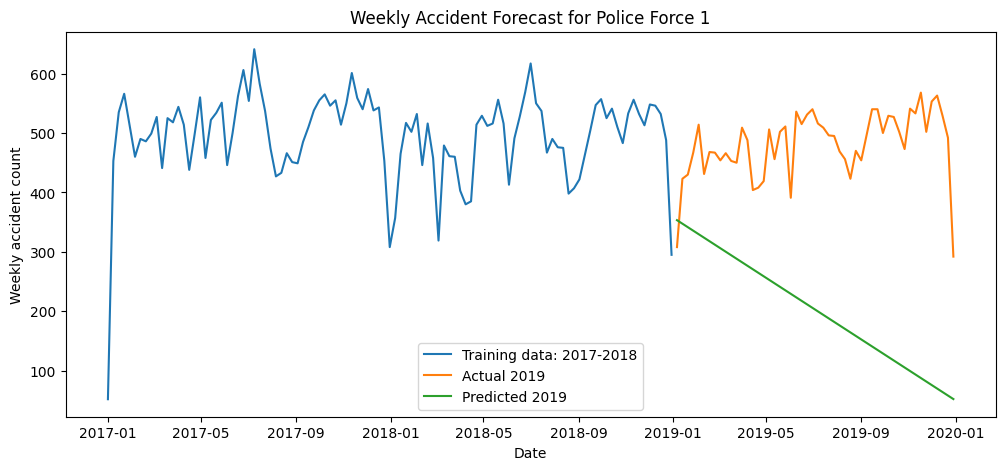

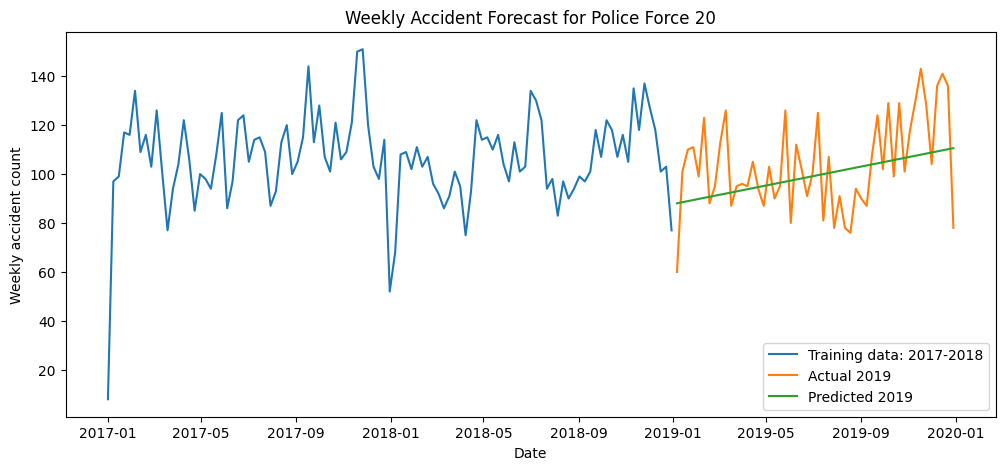

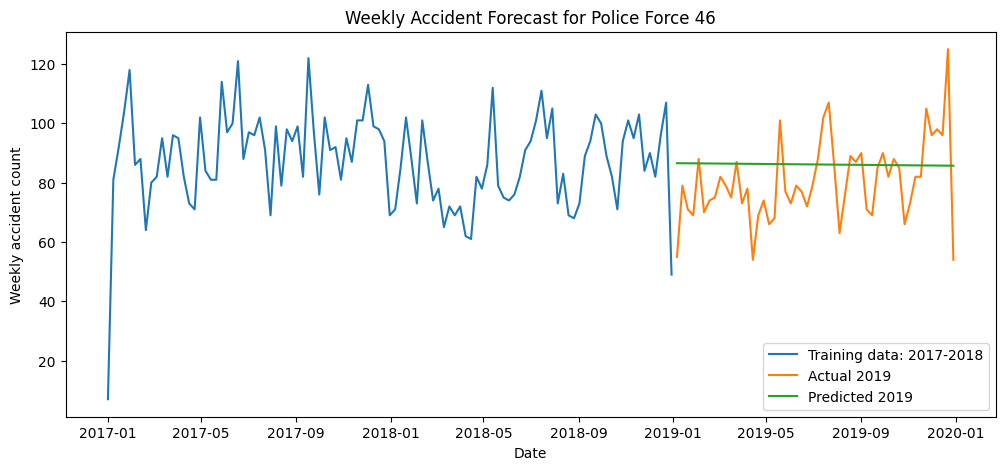

,police_force,MAE,RMSE,actual_total_2019,predicted_total_2019
0,1,280.031159,304.121943,25016,10545.019835
1,20,14.868322,18.132810,5397,5164.337019
2,46,11.966247,14.869579,4179,4480.061358


In [22]:
# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))


# Store model results
forecast_results = []

for force in chosen_forces:
    
    # Filter one police force
    force_data = accident_ts[accident_ts["police_force"] == force].copy()
    
    # Weekly accident counts
    weekly_counts = (
        force_data
        .set_index("date")
        .resample("W")["accident_index"]
        .count()
    )
    
    # Training: 2017 and 2018
    train = weekly_counts["2017-01-01":"2018-12-31"]
    
    # Testing: 2019
    test = weekly_counts["2019-01-01":"2019-12-31"]
    
    # Fit Exponential Smoothing model
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal=None
    )
    
    fitted_model = model.fit()
    
    # Forecast 2019
    forecast = fitted_model.forecast(len(test))
    forecast.index = test.index
    
    # Remove negative predictions
    forecast = forecast.clip(lower=0)
    
    # Calculate errors
    mae = mean_absolute_error(test, forecast)
    error_rmse = rmse(test, forecast)
    
    forecast_results.append({
        "police_force": force,
        "MAE": mae,
        "RMSE": error_rmse,
        "actual_total_2019": test.sum(),
        "predicted_total_2019": forecast.sum()
    })
    
    # Plot result
    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label="Training data: 2017-2018")
    plt.plot(test.index, test, label="Actual 2019")
    plt.plot(forecast.index, forecast, label="Predicted 2019")
    plt.title(f"Weekly Accident Forecast for Police Force {force}")
    plt.xlabel("Date")
    plt.ylabel("Weekly accident count")
    plt.legend()
    plt.show()


# Display forecasting accuracy
forecast_results = pd.DataFrame(forecast_results)
forecast_results

### Interpreting the Weekly Forecasts

Forecast accuracy varies substantially between police-force areas. The baseline performs reasonably for some regions but strongly under-predicts one high-volume area.

Future models could include weather, holidays, roadworks, traffic volume, and policy changes.


## Forecasting Accidents in High-Incident West Yorkshire LSOAs

The 30 West Yorkshire LSOAs with the highest accident counts from January to March 2018 are identified. Daily counts from January to June are then used to forecast July.


In [23]:
# Forecast July accidents for top 30 West Yorkshire LSOAs

# Use West Yorkshire 2018 data
wy_2018 = accident_2018[accident_2018["police_force"] == 13].copy()

# Remove missing LSOA values
wy_2018 = wy_2018.dropna(subset=["lsoa_of_accident_location"])

# Filter January to March 2018
jan_mar = wy_2018[
    (wy_2018["date"] >= "2018-01-01") &
    (wy_2018["date"] <= "2018-03-31")
]

# Find top 30 LSOAs
top30_lsoas = jan_mar["lsoa_of_accident_location"].value_counts().head(30)

top30_lsoas

lsoa_of_accident_location
E01011499    11
E01033693     8
E01011107     8
E01033010     8
E01011236     7
E01011369     7
E01010833     7
E01011569     6
E01011935     6
E01033005     6
E01011428     5
E01011523     5
E01033031     5
E01011205     5
E01011363     5
E01011130     5
E01010979     5
E01011468     5
E01011677     5
E01011297     5
E01010879     4
E01033690     4
E01011368     4
E01011057     4
E01011671     4
E01010949     4
E01010639     4
E01011472     4
E01011749     4
E01011923     4
Name: count, dtype: int64

In [24]:
# Keep data only from these top 30 LSOAs
top30_data = wy_2018[
    wy_2018["lsoa_of_accident_location"].isin(top30_lsoas.index)
]

# Daily accident counts
daily_counts = (
    top30_data
    .set_index("date")
    .resample("D")["accident_index"]
    .count()
)

# Training data: January to June 2018
train_daily = daily_counts["2018-01-01":"2018-06-30"]

# Test data: July 2018
test_daily = daily_counts["2018-07-01":"2018-07-31"]

# Fit model
daily_model = ExponentialSmoothing(
    train_daily,
    trend="add",
    seasonal=None
)

daily_fit = daily_model.fit()

# Forecast July
daily_forecast = daily_fit.forecast(len(test_daily))
daily_forecast.index = test_daily.index
daily_forecast = daily_forecast.clip(lower=0)

# Evaluate forecast
daily_mae = mean_absolute_error(test_daily, daily_forecast)
daily_rmse = rmse(test_daily, daily_forecast)

print("July forecast MAE:", daily_mae)
print("July forecast RMSE:", daily_rmse)

July forecast MAE: 0.9238767011011066
July forecast RMSE: 1.2779583618279475


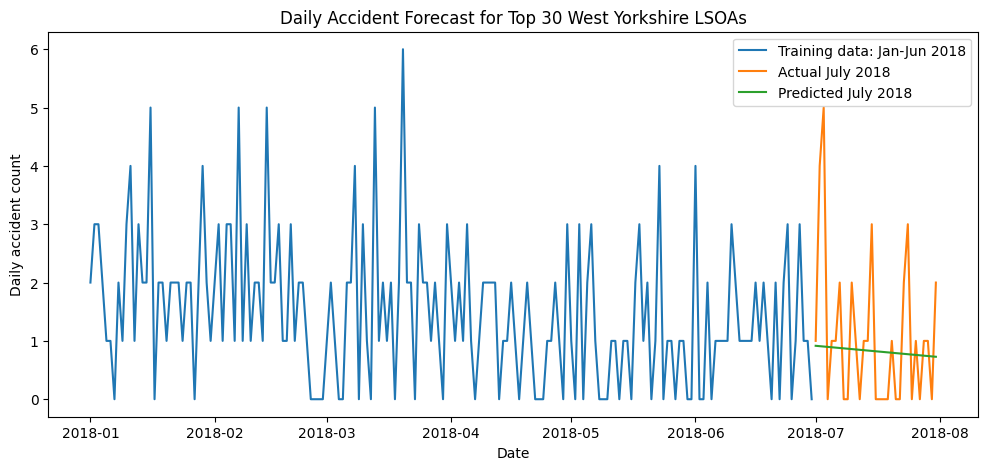

In [25]:
# Plot July forecast
plt.figure(figsize=(12, 5))
plt.plot(train_daily.index, train_daily, label="Training data: Jan-Jun 2018")
plt.plot(test_daily.index, test_daily, label="Actual July 2018")
plt.plot(daily_forecast.index, daily_forecast, label="Predicted July 2018")
plt.title("Daily Accident Forecast for Top 30 West Yorkshire LSOAs")
plt.xlabel("Date")
plt.ylabel("Daily accident count")
plt.legend()
plt.show()

### Interpreting the LSOA Forecast

The July forecast achieves an MAE of approximately **0.92 accidents per day** and an RMSE of approximately **1.28**.

The model does not reproduce every daily fluctuation, but it provides a useful baseline for low-count local planning.


## Summarising the Main Results

The final table consolidates the principal dataset sizes, statistical-test results, and forecasting metrics.


In [26]:
# Final summary table for report

summary = pd.DataFrame({
    "Item": [
        "Total accidents in 2018",
        "West Yorkshire accidents in 2018",
        "Motorcycle accident records in 2018",
        "Pedestrian casualties in 2018",
        "Task 1 hour p-value",
        "Task 1 day p-value",
        "Task 3 pedestrian hour p-value",
        "Task 3 pedestrian day p-value",
        "Task 7 July forecast MAE",
        "Task 7 July forecast RMSE"
    ],
    "Value": [
        len(accident_2018),
        len(west_yorkshire),
        len(motorcycle),
        len(pedestrian),
        p_hour,
        p_day,
        p_ped_hour,
        p_ped_day,
        daily_mae,
        daily_rmse
    ]
})

summary

,Item,Value
0,Total accidents in 2018,1.226350e+05
1,West Yorkshire accidents in 2018,4.132000e+03
2,Motorcycle accident records in 2018,1.747800e+04
3,Pedestrian casualties in 2018,2.243200e+04
4,Task 1 hour p-value,0.000000e+00
5,Task 1 day p-value,8.872809e-299
6,Task 3 pedestrian hour p-value,0.000000e+00
7,Task 3 pedestrian day p-value,1.005963e-144
8,Task 7 July forecast MAE,9.238767e-01
9,Task 7 July forecast RMSE,1.277958e+00


## Recognising the Limitations

- The data contain reported injury accidents rather than every road incident.
- Counts are not adjusted for exposure such as traffic volume or pedestrian activity.
- Apriori and clustering identify patterns but do not establish causes.
- The forecasting models are deliberately simple baselines.
- Spatial clusters require local contextual and engineering investigation.


## Concluding the Analysis

The project demonstrates clear temporal, road-user, spatial, and contextual structure in UK road-traffic accidents. Afternoon and early-evening periods show elevated activity, pedestrian casualties cluster around school and commuting times, and West Yorkshire contains identifiable spatial concentrations.

The forecasting results also show why models must be evaluated separately across locations: adequate performance in one region does not guarantee reliable performance elsewhere.


In [27]:
# Close database connection

conn.close()